# **XV-15 Rotor**

The [XV-15 tiltrotor aircraft](https://history.nasa.gov/monograph17.pdf) is a commonly used test bed for propeler validation work. Its rotor geometry will be used to quickly run an isolated rotor simulation.

The flow conditions in this case are:
- Airspeed = 5 m/s
- Rotation rate = 600 RPM
- Density = 1.225 $kg/m^3$
- Alpha = -90°, air coming down from above (i.e. an ascent case)

Other key considerations:
- The reference velocity magnitude is arbitrarily set to the tip velocity of the blades
- The simulation will run 3° per time step for 5 revolutions, which results in 600 steps

## Imports

First, we import `flow360` and `TutorialRANSXv15`.

In [1]:
# Flow360 imports
import flow360 as fl
from flow360.examples import TutorialRANSXv15

# We also import and change the log settings to only see ones of level INFO or higher
from flow360.log import log, set_logging_level
log.log_to_file = False
set_logging_level("INFO")

We also have to download the files from `TutorialRANSXv15` using `get_files()`.

In [2]:
TutorialRANSXv15.get_files()

The mesh file is also available [here](https://simcloud-public-1.s3.amazonaws.com/xv15/XV15_Hover_ascent_coarse_v2.cgns).

## Project creation

Project is created using `fl.Project.from_file(...)`. It is also possible to run cases based on an existing project by using `fl.Project.from_cloud(...)` instead and providing ID for the project you want to use.

In [3]:
project = fl.Project.from_file(TutorialRANSXv15.mesh_filename,name="XV-15 Quick Start")

Output()

Output()

[12:08:36] INFO: VolumeMesh successfully submitted:                                                                
                   name   = XV-15 Quick Start                                                                      
                   id     = vm-c37b95ff-fd4d-4f23-b45c-f9987ca5007a                                                
                   status = uploaded                                                                               
           

Now we will create a `volume_mesh` variable that will be `project`'s volume mesh.

In [4]:
volume_mesh = project.volume_mesh

## Simulation parameters

We utilize the `SimulationParams` class to create `paramas` variable that will have settings for our case.

In [5]:
# Use SI units
with fl.SI_unit_system:

    # Create rotation zone entity
    rotation_zone = volume_mesh["innerRotating"]
    rotation_zone.center = (0, 0, 0) * fl.u.m
    rotation_zone.axis = (0, 0, -1)

    # Simulation parameters
    params = fl.SimulationParams(

        # Reference geometrical values
        reference_geometry=fl.ReferenceGeometry(
            moment_center=(0, 0, 0),
            moment_length=(3.81, 3.81, 3.81),
            area=45.604,
        ),

        # Operating conditions of the flow in the freestream
        operating_condition=fl.AerospaceCondition(
            velocity_magnitude=5,
            alpha=-90 * fl.u.deg,
            reference_velocity_magnitude=238.14,
        ),

        # Time stepping method set to transient
        time_stepping=fl.Unsteady(
            max_pseudo_steps=35,
            steps=600,
            step_size=0.5 / 600 * fl.u.s,
            CFL=fl.AdaptiveCFL(),
        ),

        # Models with boundary conditions and solver settings.
        models=[
            fl.Fluid(
                navier_stokes_solver=fl.NavierStokesSolver(
                    absolute_tolerance=1e-9,
                    linear_solver=fl.LinearSolver(max_iterations=35),
                    limit_velocity=True,
                    limit_pressure_density=True,
                ),
                turbulence_model_solver=fl.SpalartAllmaras(
                    absolute_tolerance=1e-8,
                    linear_solver=fl.LinearSolver(max_iterations=25),
                    DDES=True,
                    rotation_correction=True,
                    equation_evaluation_frequency=1,
                ),
            ),

            # Rotation settings
            fl.Rotation(
                volumes=rotation_zone,
                spec=fl.AngularVelocity(600 * fl.u.rpm),
            ),
            fl.Freestream(surfaces=volume_mesh["farField/farField"], name="Freestream"),
            fl.Wall(surfaces=volume_mesh["innerRotating/blade"], name="NoSlipWall"),
        ],

        # Outputs for post-processing purposes
        outputs=[
            fl.VolumeOutput(
                name="VolumeOutput",
                output_fields=[
                    "primitiveVars",
                    "T",
                    "Cp",
                    "Mach",
                    "qcriterion",
                    "VelocityRelative",
                ],
            ),
            fl.SurfaceOutput(
                name="SurfaceOutput",
                surfaces=volume_mesh["*"],
                output_fields=[
                    "primitiveVars",
                    "Cp",
                    "Cf",
                    "yPlus",
                    "nodeForcesPerUnitArea",
                ],
            ),
        ],
    )

[12:08:56] INFO: using: SI unit system for unit inference.

## Running the case

With `params` defined and our mesh uploaded, we can run the case.

In [6]:
project.run_case(params=params, name="Case of XV-15 Quick Start")

## Post processing

To have a better understanding of the results obtained from the simulation, we will post-process and display them in the form of plots.

In [7]:
case = project.case

# Wait for the case to finish
case.wait()

Download and convert the files into pandas dataframe.

In [8]:
nonlinear_residuals = case.results.nonlinear_residuals
nonlinear_residuals = nonlinear_residuals.as_dataframe()

total_forces = case.results.total_forces
total_forces = total_forces.as_dataframe()

Output()

[12:18:39] INFO: Saved to                                                                                          
           /var/folders/qk/mywsrvps5gl_f3yjx2k1v1xm0000gn/T/tmpi644z2ki/3fc3b755-dd05-47b3-b076-b7193f2c77b6.csv

Output()

[12:18:49] INFO: Saved to                                                                                          
           /var/folders/qk/mywsrvps5gl_f3yjx2k1v1xm0000gn/T/tmpi644z2ki/40b61d46-980f-4ca5-8da9-209a1c23659d.csv

The convergence of non-linear resiudals can be shown with the following.

<Axes: xlabel='Physical Step', ylabel='residuals'>

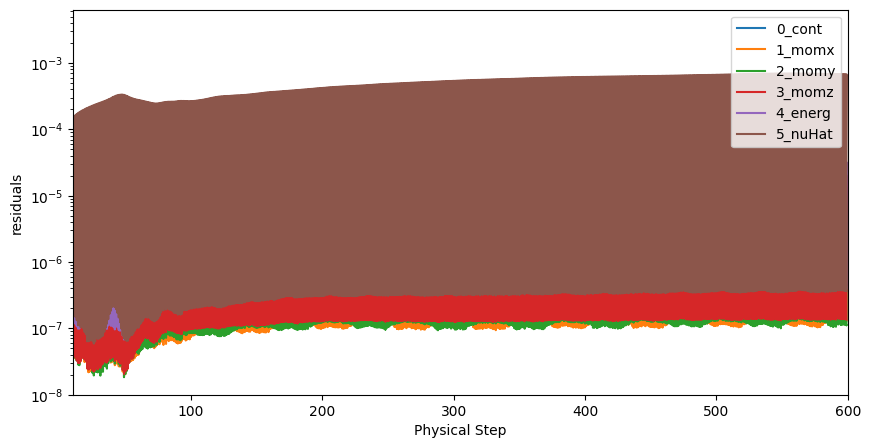

In [9]:
nonlinear_residuals.plot(x='physical_step',
                         y=["0_cont", "1_momx", "2_momy", "3_momz", "4_energ", "5_nuHat"],
                         logy=True,
                         xlim=(10, 600),
                         xlabel="Physical Step",
                         ylabel="residuals",
                         figsize=(10, 5)
)

Values of nondimensional forces and moments can be accessed in `total_forces` and plotted against physical time step.

array([<Axes: xlabel='Physical Step'>, <Axes: xlabel='Physical Step'>,
       <Axes: xlabel='Physical Step'>], dtype=object)

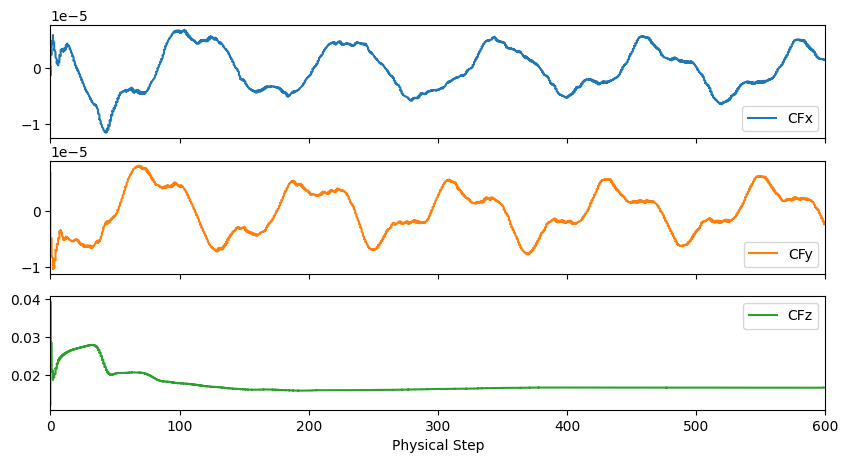

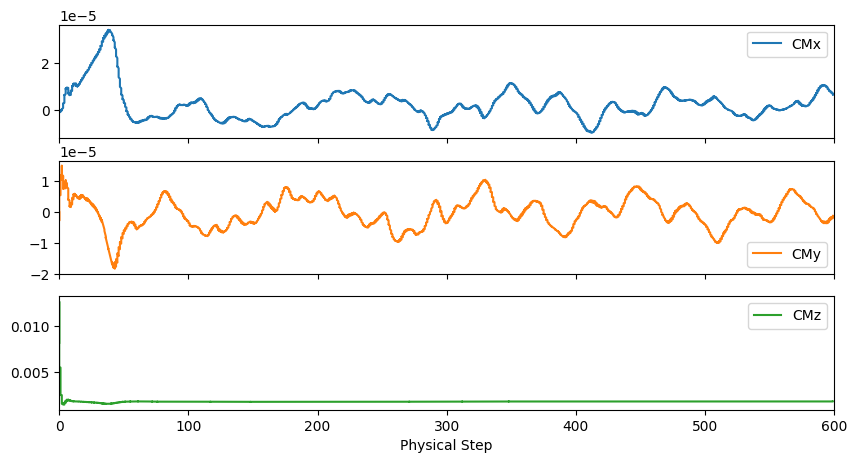

In [10]:
total_forces.plot(x="physical_step",
                  y=["CFx", "CFy", "CFz"],
                  xlabel="Physical Step",
                  xlim=(0, 600),
                  figsize=(10, 5),
                  subplots=True,
)
total_forces.plot(x="physical_step",
                  y=["CMx", "CMy", "CMz"],
                  xlabel="Physical Step",
                  xlim=(0, 600),
                  figsize=(10, 5),
                  subplots=True,
)

For more information about this Quick Start case, visit the [Flow360 documentation](https://docs.flexcompute.com/projects/flow360/en/latest/quickStart/Propeller_XV15/Propeller_XV15.html).